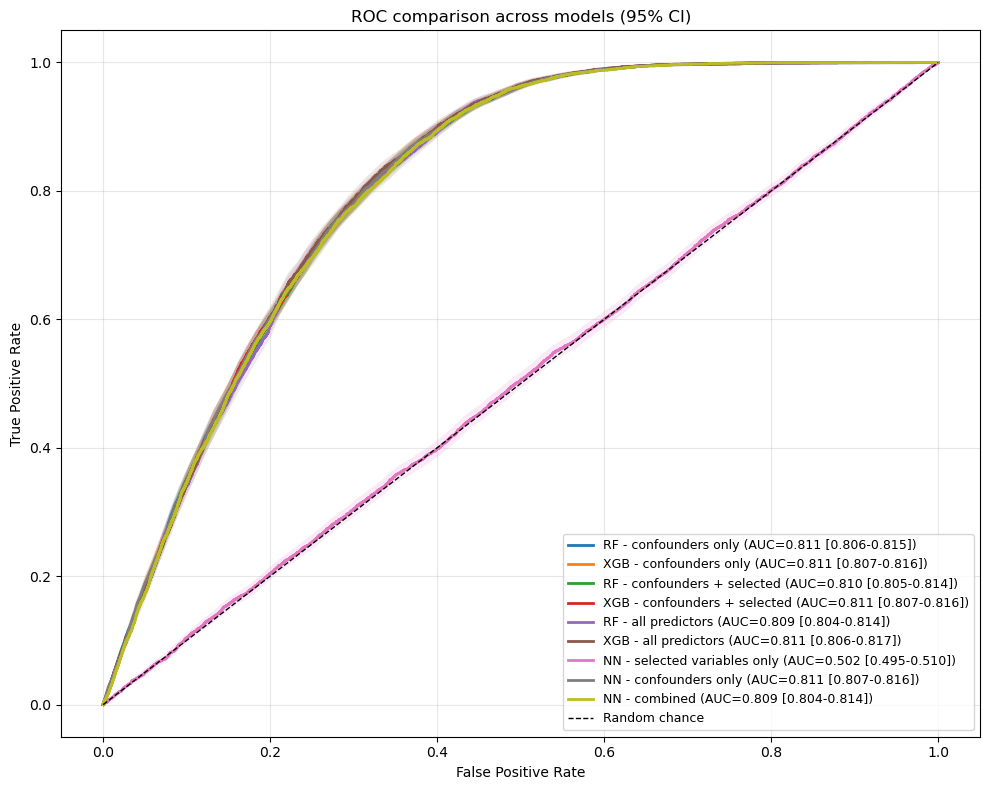

/rds/general/project/hda_25-26/live/TDS/fg520/TDS-Group-4/02_results/03_ml/combined_model_family_roc_comparison_with_ci.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.utils import resample

BASE = Path("/rds/general/project/hda_25-26/live/TDS/fg520/TDS-Group-4/02_results/03_ml")

files = {
    "RF - confounders only": BASE / "tree_models_python_confounders" / "test_predictions.csv",
    "XGB - confounders only": BASE / "tree_models_python_confounders" / "test_predictions.csv",

    "RF - confounders + selected": BASE / "tree_models_python_confounders_plus_selected" / "test_predictions.csv",
    "XGB - confounders + selected": BASE / "tree_models_python_confounders_plus_selected" / "test_predictions.csv",

    "RF - all predictors": BASE / "tree_models_python_all" / "test_predictions.csv",
    "XGB - all predictors": BASE / "tree_models_python_all" / "test_predictions.csv",

    "NN - selected variables only": BASE / "nn_outputs" / "nn_test_predictions.csv",
    "NN - confounders only": BASE / "nn_outputs" / "nn_test_predictions.csv",
    "NN - combined": BASE / "nn_outputs" / "nn_test_predictions.csv",
}

prob_cols = {
    "RF - confounders only": "rf_prob",
    "XGB - confounders only": "xgb_prob",

    "RF - confounders + selected": "rf_prob",
    "XGB - confounders + selected": "xgb_prob",

    "RF - all predictors": "rf_prob",
    "XGB - all predictors": "xgb_prob",

    "NN - selected variables only": "exposome_only_stability_selected_prob",
    "NN - confounders only": "demographics_only_age_sex_ethnicity_prob",
    "NN - combined": "combined_exposome_plus_demographics_prob",
}


def bootstrap_roc_ci(y_true, y_prob, n_bootstrap=1000, random_state=42):
    rng = np.random.RandomState(random_state)

    fpr_grid = np.linspace(0, 1, 100)
    tprs = []
    aucs = []

    y_true = pd.Series(y_true).reset_index(drop=True)
    y_prob = np.asarray(y_prob)

    for _ in range(n_bootstrap):
        idx = resample(np.arange(len(y_true)), replace=True, random_state=rng)

        if len(np.unique(y_true.iloc[idx])) < 2:
            continue

        y_true_bs = y_true.iloc[idx]
        y_prob_bs = y_prob[idx]

        fpr, tpr, _ = roc_curve(y_true_bs, y_prob_bs)
        aucs.append(roc_auc_score(y_true_bs, y_prob_bs))

        tpr_interp = np.interp(fpr_grid, fpr, tpr)
        tpr_interp[0] = 0.0
        tprs.append(tpr_interp)

    tprs = np.array(tprs)
    aucs = np.array(aucs)

    return {
        "fpr_grid": fpr_grid,
        "tpr_lower": np.percentile(tprs, 2.5, axis=0),
        "tpr_upper": np.percentile(tprs, 97.5, axis=0),
        "auc_lower": np.percentile(aucs, 2.5),
        "auc_upper": np.percentile(aucs, 97.5),
    }


plt.figure(figsize=(10, 8))

for label, path in files.items():
    df = pd.read_csv(path)
    y_true = df["y_true"]
    y_prob = df[prob_cols[label]]

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    ci = bootstrap_roc_ci(y_true, y_prob)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{label} (AUC={auc:.3f} [{ci['auc_lower']:.3f}-{ci['auc_upper']:.3f}])"
    )

    plt.fill_between(
        ci["fpr_grid"],
        ci["tpr_lower"],
        ci["tpr_upper"],
        alpha=0.15
    )

plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC comparison across models (95% CI)")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()

out_path = BASE / "combined_model_family_roc_comparison_with_ci.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(out_path)